# Dijkstra's Algorithm

**Domain:** `data-structures-algorithms`
**Level:** Beginner-friendly intro, intermediate rigor
**Prerequisites:** Basic programming (loops, arrays/lists); helpful (not required) to have seen a graph/adjacency list before
**Language:** C++ (real, compiled, and executed — see `src/`)

Imagine you're planning a road trip. Your GPS doesn't just look for *any*
route from your house to your destination — it's hunting for the route that
costs the least total *driving time*, across a tangle of roads that all have
different lengths and speed limits. Some "shorter" looking roads are
actually slower; some longer detours are faster highways. The GPS has to
account for all of that at once.

Here's the trick your GPS effectively uses: start at home, and always
expand outward to whichever nearby city has the **cheapest total travel
time found so far**, before looking any further afield. Every time you
arrive at a new city via some route, check whether that route beats the
best one you already knew about — if so, update it. Keep doing this,
closest-known-city first, and by the time you've visited every reachable
city, you've provably found the cheapest way to reach each one.

That's **Dijkstra's algorithm** — a way to find the shortest (cheapest)
path from one starting point to every other point in a network of
weighted connections, as long as none of those connections have a
negative cost.

By the end of this tutorial you'll be able to: explain *why* the
"always expand the closest unvisited node next" strategy is guaranteed to
find true shortest paths, prove that guarantee (and see exactly where it
breaks), derive Dijkstra's $O((V + E)\log V)$ running time, and run a real,
compiled C++ implementation that reports its own relaxation count and
wall-clock time.

## The idea, intuitively

Think of every node (city) as having a sticky note on it: **"best known
distance from home so far."** At the very start, every sticky note says
$\infty$ except home's, which says $0$ — you don't know a route to
anywhere else yet.

The algorithm then repeats one simple loop:

1. **Pick the unvisited node with the smallest sticky-note number.** This
   node's number can never improve again, so we **finalize** it — it's
   "locked in" as the true shortest distance from home.
2. **Look at all of that node's outgoing roads.** For each neighbor, check:
   *"if I go through the node I just finalized, is that cheaper than the
   neighbor's current sticky note?"* If yes, cross out the neighbor's old
   number and write in the cheaper one. This update step is called
   **relaxation** — you're "relaxing" (loosening) an overly pessimistic
   distance estimate.
3. Repeat until every reachable node has been finalized.

That's the whole algorithm. **The one operation that matters is
relaxation** — everything else is bookkeeping about which node to relax
from next (always the closest unvisited one).

Here's relaxation as actual code, on a tiny toy graph, before any
implementation details:

In [1]:
# A toy adjacency structure: city -> list of (neighbor, road_cost)
toy_graph = {
    "A": [("B", 4), ("C", 2)],
    "B": [("C", 5), ("D", 10)],
    "C": [("B", 1), ("E", 3)],
    "D": [("F", 11)],
    "E": [("D", 4), ("F", 5)],
    "F": [],
}

# sticky notes: best known distance from "A" to every node, so far
dist = {node: float("inf") for node in toy_graph}
dist["A"] = 0


def relax(dist, u, v, weight):
    # One relaxation: can we reach v more cheaply by going through u?
    candidate = dist[u] + weight
    if candidate < dist[v]:
        print(f"relax({u}->{v}): {dist[v]} -> {candidate}  (improved)")
        dist[v] = candidate
        return True
    print(f"relax({u}->{v}): {dist[v]} stays (candidate was {candidate})")
    return False


# A single relaxation step: A has a direct road to C with cost 2.
relax(dist, "A", "C", 2)
print("distances so far:", dist)

relax(A->C): inf -> 2  (improved)
distances so far: {'A': 0, 'B': inf, 'C': 2, 'D': inf, 'E': inf, 'F': inf}


**Takeaway:** relaxation is just "is going through this node a
shortcut?" — a two-line comparison, run over and over. Dijkstra's algorithm
is nothing more than *always relaxing from the cheapest unvisited node
next*, so that once a node's sticky note is finalized, no later relaxation
can ever beat it (we'll prove exactly why in the next section).

### Hand-tracing the full toy graph

Let's run the whole algorithm by hand on `toy_graph` above, starting from
`A`. At each step we finalize the smallest unvisited sticky note and relax
its outgoing roads:

| Step | Node finalized | dist A | dist B | dist C | dist D | dist E | dist F |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| start | — | **0** | ∞ | ∞ | ∞ | ∞ | ∞ |
| 1 | A (0) | 0 | 4 | 2 | ∞ | ∞ | ∞ |
| 2 | C (2) | 0 | **3** | 2 | ∞ | 5 | ∞ |
| 3 | B (3) | 0 | 3 | 2 | 13 | 5 | ∞ |
| 4 | E (5) | 0 | 3 | 2 | **9** | 5 | 10 |
| 5 | D (9) | 0 | 3 | 2 | 9 | 5 | 10 |
| 6 | F (10) | 0 | 3 | 2 | 9 | 5 | 10 |

Two updates are worth pausing on:

- At step 2, finalizing `C` relaxes `C -> B` (cost 1), which **beats** the
  distance-4 route `A -> B` found at step 1 — B's sticky note improves
  from 4 to 3.
- At step 4, finalizing `E` relaxes `E -> D` (cost 4), which beats the
  distance-13 route `B -> D` found at step 3 — D's sticky note improves
  from 13 down to 9.

This is exactly why we don't finalize a node the *first* time we hear
about it — we wait until it has the smallest sticky note among everything
still unvisited, because a cheaper route via some other, not-yet-explored
node might still show up. We'll verify this exact trace against the real
compiled program later in this tutorial.

## Going deeper: the formal definition

*(This section proves the claims made above. If you just want to see it
run, skip to "Visuals" below.)*

### Setup

Let $G = (V, E)$ be a directed graph with non-negative edge weights
$w: E \to \mathbb{R}_{\ge 0}$, and a source node $s \in V$. Define
$\delta(s, u)$ as the true shortest-path distance from $s$ to $u$ (the
quantity we're trying to compute for every $u$).

Dijkstra's algorithm maintains, for every node $u$, an estimate
$\text{dist}[u]$ (initialized to $\infty$, except $\text{dist}[s] = 0$) and
a set $S$ of **finalized** nodes (initially empty).

### The relaxation operation, formally

For an edge $(u, v)$ with weight $w(u, v)$:

$$
\text{RELAX}(u, v):\quad \text{if } \text{dist}[v] > \text{dist}[u] + w(u, v):\ \ \text{dist}[v] \leftarrow \text{dist}[u] + w(u, v)
$$

This is exactly the two-line comparison from the code above. Relaxation
never makes $\text{dist}[v]$ *worse* — it only tightens an estimate that
was too pessimistic, and it can never produce a value smaller than the
truth, since it always corresponds to *some* real walk from $s$ to $v$.

### The algorithm

$$
\begin{aligned}
&\text{dist}[s] \leftarrow 0,\quad \text{dist}[u] \leftarrow \infty \text{ for all other } u,\quad S \leftarrow \varnothing \\
&\textbf{while } S \ne V: \\
&\quad u \leftarrow \arg\min_{v \notin S} \text{dist}[v] \qquad \text{(the greedy choice)} \\
&\quad S \leftarrow S \cup \{u\} \qquad \text{(finalize } u\text{)} \\
&\quad \textbf{for each } (u, v) \in E: \text{ RELAX}(u, v)
\end{aligned}
$$

### Correctness: why the greedy choice works

**Claim.** Every time a node $u$ is added to $S$ (finalized), $\text{dist}[u] = \delta(s, u)$.

**Proof, by strong induction on the order in which nodes are finalized.**

*Base case.* The first node finalized is $s$ itself, with $\text{dist}[s] = 0 = \delta(s, s)$.

*Inductive step.* Suppose the claim holds for every node finalized so far
(i.e. for every $x \in S$, $\text{dist}[x] = \delta(s, x)$). Let $u$ be the
next node the algorithm is about to finalize, chosen because
$\text{dist}[u]$ is smallest among all unfinalized nodes. Suppose, for
contradiction, that $\text{dist}[u] > \delta(s, u)$ — i.e. a cheaper true
path to $u$ exists than what we've found.

Consider a shortest path $P$ from $s$ to $u$ (length $\delta(s, u)$). Since
$s \in S$ and $u \notin S$, $P$ must cross from $S$ to outside $S$
somewhere; let $y$ be the **first** node on $P$ that is not in $S$, and let
$x$ be its predecessor on $P$ (possibly $x = s$), so $x \in S$.

- By the inductive hypothesis, $\text{dist}[x] = \delta(s, x)$, and since
  $(x, y)$ was relaxed the moment $x$ was finalized,
  $\text{dist}[y] \le \text{dist}[x] + w(x, y) = \delta(s, x) + w(x, y) = \delta(s, y)$
  (the last equality holds because the prefix of a shortest path is itself
  a shortest path). Combined with the fact that relaxation never
  undershoots the truth, $\text{dist}[y] = \delta(s, y)$.
- $y$ lies on the shortest path $P$ to $u$, and the remainder of $P$ from
  $y$ to $u$ has **non-negative** total length (every edge weight is
  $\ge 0$), so $\delta(s, y) \le \delta(s, u)$.
- Chaining these: $\text{dist}[y] = \delta(s, y) \le \delta(s, u) < \text{dist}[u]$.

But $y$ is unfinalized and $\text{dist}[y] < \text{dist}[u]$ — contradicting
that $u$ was the *minimum*-distance unfinalized node the algorithm chose to
finalize next. So the assumption was false: $\text{dist}[u] = \delta(s, u)$. $\blacksquare$

**This is the crux of the whole algorithm.** The proof leans on exactly one
inequality: $\delta(s, y) \le \delta(s, u)$, which holds *only* because the
remaining stretch of path from $y$ to $u$ cannot have negative total
length. Non-negative edge weights are what make "closest known node next"
a *safe* greedy choice — finalizing it can never later turn out to have
been premature.

### Why negative edge weights break it

If edges can be negative, that one inequality can fail: a path that looks
expensive right now can become cheap later thanks to a negative edge
further along, *after* the algorithm has already committed to (finalized)
a worse answer.

Concretely: take three nodes $s, x, y$ with directed edges
$s \to y$ (weight $1$), $s \to x$ (weight $2$), $x \to y$ (weight $-3$).

- The true shortest path $s \to y$ is $s \to x \to y$, with cost
  $2 + (-3) = -1$.
- But Dijkstra relaxes $s$'s edges first: $\text{dist}[y] = 1$,
  $\text{dist}[x] = 2$. Since $\text{dist}[y] = 1 < \text{dist}[x] = 2$,
  $y$ is finalized **immediately**, locking in $\text{dist}[y] = 1$.
- Only afterward does $x$ get finalized and relax $x \to y$, discovering
  the candidate $2 + (-3) = -1$ — but $y$ is already finalized, so a
  correct implementation (this one included) will not revisit it.
  Dijkstra reports $\text{dist}[y] = 1$: **wrong**, off by 2.

We'll run this exact three-node graph through the real compiled program
later in this tutorial and watch it produce that wrong answer, live.

### Complexity: deriving $O((V + E)\log V)$

With the priority queue backed by a **binary heap** (as in this
tutorial's `std::priority_queue`):

- Every node is extracted as the minimum exactly once: $V$ calls to
  extract-min, each $O(\log V)$ on a heap of up to $V$ entries — total
  $O(V \log V)$.
- Every edge is relaxed at most once (when its source node is finalized).
  A successful relaxation pushes a new $(\text{dist}, \text{node})$ pair
  into the heap — an $O(\log V)$ insert. That's $E$ pushes, total
  $O(E \log V)$.
- (This implementation uses **lazy deletion**: instead of a true
  decrease-key, it just pushes a fresh, better entry and skips stale ones
  when popped — a standard, simpler alternative to a decrease-key-capable
  heap, at the cost of the heap holding up to $O(E)$ entries instead of
  $O(V)$, which doesn't change the asymptotic bound.)

Summing: $O(V \log V) + O(E \log V) = O((V + E) \log V)$.

With a **Fibonacci heap**, decrease-key drops to $O(1)$ amortized instead
of $O(\log V)$, giving the theoretically optimal
$O(E + V \log V)$ (Fredman & Tarjan, 1987) — mentioned here as a forward
reference; this tutorial's implementation uses the simpler, practically
faster-in-most-cases binary heap.

## Visuals

Both visuals below use **real output from the compiled C++ program** in
`src/dijkstra.cpp` — not a Python re-implementation. First, compile it.

In [2]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
exe_path = src_dir / "dijkstra.exe"

compile_cmd = [
    "g++", "-O2", "-std=c++17",
    "-static", "-static-libgcc", "-static-libstdc++",
    str(src_dir / "dijkstra.cpp"), "-o", str(exe_path),
]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
print("compiled successfully ->", exe_path)

compile return code: 0
compiled successfully -> src\dijkstra.exe


In [3]:
def run_dijkstra(V, edges, source=0):
    # Run the real compiled dijkstra binary on a directed weighted edge list
    # [(u, v, w), ...]; returns {'dist': {...}, 'relaxations': int, 'microseconds': int}.
    E = len(edges)
    lines = [f"{V} {E} {source}"] + [f"{u} {v} {w}" for u, v, w in edges]
    input_str = "\n".join(lines) + "\n"
    proc = subprocess.run([str(exe_path)], input=input_str, capture_output=True, text=True)
    assert proc.returncode == 0, proc.stderr

    dist = {}
    stats = {}
    for line in proc.stdout.strip().splitlines():
        if line.startswith("dist "):
            _, node, d = line.split()
            dist[int(node)] = None if d == "INF" else int(d)
        elif "=" in line:
            key, val = line.split("=")
            stats[key] = int(val)
    stats["dist"] = dist
    return stats


# The same 6-node graph from the hand trace, with letters mapped to ints.
labels = ["A", "B", "C", "D", "E", "F"]
label_to_idx = {c: i for i, c in enumerate(labels)}
toy_edges_named = [
    ("A", "B", 4), ("A", "C", 2), ("B", "C", 5), ("B", "D", 10),
    ("C", "B", 1), ("C", "E", 3), ("D", "F", 11), ("E", "D", 4), ("E", "F", 5),
]
toy_edges = [(label_to_idx[u], label_to_idx[v], w) for u, v, w in toy_edges_named]

result = run_dijkstra(len(labels), toy_edges, source=label_to_idx["A"])
print("distances from A:", {labels[k]: v for k, v in sorted(result["dist"].items())})
print("relaxations:", result["relaxations"])
print("microseconds:", result["microseconds"])

expected = {"A": 0, "B": 3, "C": 2, "D": 9, "E": 5, "F": 10}
assert {labels[k]: v for k, v in result["dist"].items()} == expected
print("\nmatches the hand-traced table above")

distances from A: {'A': 0, 'B': 3, 'C': 2, 'D': 9, 'E': 5, 'F': 10}
relaxations: 7
microseconds: 2

matches the hand-traced table above


### The graph, with real computed distances

Nodes are colored by their finalized shortest distance from `A` (source
node outlined in black), and edges are labeled with their weight — exactly
as reported by the compiled program above.

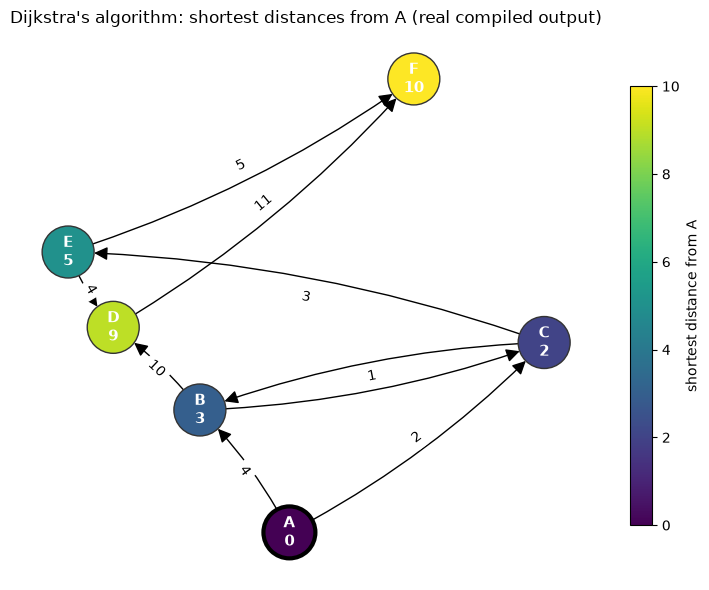

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx

G = nx.DiGraph()
for u, v, w in toy_edges_named:
    G.add_edge(u, v, weight=w)

pos = nx.spring_layout(G, seed=7)
dist_by_label = {labels[k]: v for k, v in result["dist"].items()}
node_colors = [dist_by_label[n] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(7.5, 6))
cmap = plt.cm.viridis
nodes = nx.draw_networkx_nodes(
    G, pos, ax=ax, node_color=node_colors, cmap=cmap, node_size=1400,
    edgecolors=["black" if n == "A" else "#333333" for n in G.nodes()],
    linewidths=[3 if n == "A" else 1 for n in G.nodes()],
)
nx.draw_networkx_edges(
    G, pos, ax=ax, arrowsize=20, node_size=1400, connectionstyle="arc3,rad=0.08",
)
nx.draw_networkx_labels(
    G, pos, ax=ax,
    labels={n: f"{n}\n{dist_by_label[n]}" for n in G.nodes()},
    font_size=11, font_color="white", font_weight="bold",
)
nx.draw_networkx_edge_labels(
    G, pos, ax=ax, edge_labels=nx.get_edge_attributes(G, "weight"), font_size=10,
)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label("shortest distance from A")
ax.set_title("Dijkstra's algorithm: shortest distances from A (real compiled output)")
ax.axis("off")
plt.tight_layout()
plt.savefig("dijkstra_graph.png", dpi=110)
plt.show()

### Runtime vs. graph size: confirming $O((V + E)\log V)$

We generate random, connected, sparse directed graphs of growing size
(edge count $\approx 4V$, so $V + E$ grows linearly with $V$), run each one
through the real compiled binary, and plot the **program's own reported
microsecond timing** against $V + E$.

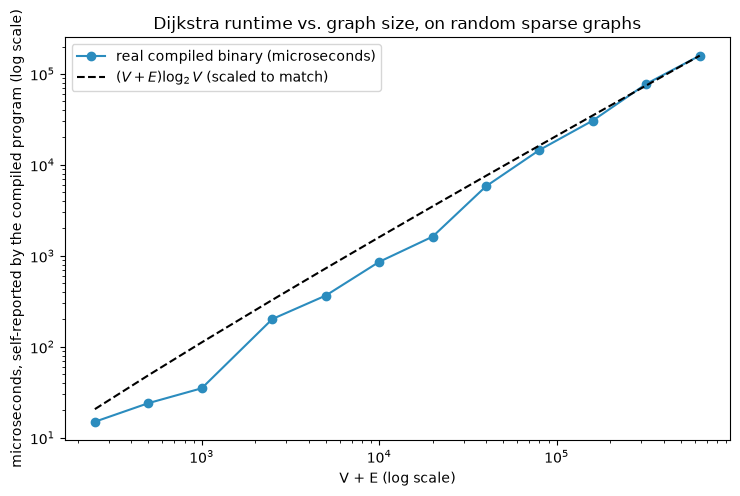

V=    50  V+E=    250  microseconds=      15
V=   100  V+E=    500  microseconds=      24
V=   200  V+E=   1000  microseconds=      35
V=   500  V+E=   2500  microseconds=     202
V=  1000  V+E=   5000  microseconds=     366
V=  2000  V+E=  10000  microseconds=     859
V=  4000  V+E=  20000  microseconds=    1626
V=  8000  V+E=  40000  microseconds=    5821
V= 16000  V+E=  80000  microseconds=   14579
V= 32000  V+E= 160000  microseconds=   30735
V= 64000  V+E= 320000  microseconds=   77785
V=128000  V+E= 640000  microseconds=  158818


In [5]:
import random
import numpy as np

def random_sparse_graph(V, edge_multiplier=4, seed=0):
    rng = random.Random(seed)
    edges = []
    # A random spanning structure guarantees every node is reachable from 0.
    for v in range(1, V):
        u = rng.randint(0, v - 1)
        edges.append((u, v, rng.randint(1, 100)))
    target = edge_multiplier * V
    while len(edges) < target:
        u, v = rng.randint(0, V - 1), rng.randint(0, V - 1)
        if u != v:
            edges.append((u, v, rng.randint(1, 100)))
    return edges


sizes = [50, 100, 200, 500, 1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000]
ve_totals, real_micros = [], []

for V in sizes:
    edges = random_sparse_graph(V, edge_multiplier=4, seed=V)
    E = len(edges)
    # take the minimum of 3 trials to reduce OS scheduling noise
    trial_times = [run_dijkstra(V, edges, source=0)["microseconds"] for _ in range(3)]
    real_micros.append(min(trial_times))
    ve_totals.append(V + E)

ve_arr = np.array(ve_totals, dtype=float)
v_arr = np.array(sizes, dtype=float)
theory = ve_arr * np.log2(v_arr)
theory_scaled = theory * (real_micros[-1] / theory[-1])  # anchor to the largest real point

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(ve_totals, real_micros, "o-", color="#2b8cbe", label="real compiled binary (microseconds)")
ax.plot(ve_totals, theory_scaled, "k--", label=r"$(V+E)\log_2 V$ (scaled to match)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("V + E (log scale)")
ax.set_ylabel("microseconds, self-reported by the compiled program (log scale)")
ax.set_title("Dijkstra runtime vs. graph size, on random sparse graphs")
ax.legend()
plt.tight_layout()
plt.savefig("dijkstra_runtime.png", dpi=110)
plt.show()

for V, ve, us in zip(sizes, ve_totals, real_micros):
    print(f"V={V:6d}  V+E={ve:7d}  microseconds={us:8d}")

On a log-log plot, the real timings track the $(V+E)\log_2 V$ curve
closely across more than three orders of magnitude of graph size — the
theoretical bound derived above isn't just an asymptotic abstraction, it's
what the compiled program actually does.

## Implementation

The reference implementation lives in
[`src/dijkstra.cpp`](src/dijkstra.cpp) — real C++, using:

- an **adjacency list** (`std::vector<std::vector<Edge>>`) rather than an
  adjacency matrix, since real-world graphs (road networks, computer
  networks) are typically sparse ($E \ll V^2$);
- a **binary min-heap** (`std::priority_queue` of `(distance, node)` pairs,
  ordered smallest-first via `std::greater`) as the priority queue driving
  the greedy "closest unvisited node next" choice;
- **lazy deletion** for the decrease-key operation: rather than mutating an
  entry inside the heap (which `std::priority_queue` doesn't support),
  the code just pushes a fresh `(new_distance, node)` pair whenever a
  relaxation improves a distance, and skips any popped entry that's now
  stale (`if (d > dist[u]) continue;`);
- instrumentation counting every successful relaxation and timing the
  whole run with `std::chrono::high_resolution_clock`.

It reads `V E source` on the first line, followed by `E` lines of
`u v w` (a directed edge `u -> v` with weight `w`), and prints each node's
shortest distance from `source`, the relaxation count, and the elapsed
microseconds — exactly the fields parsed by `run_dijkstra()` above.

### Watching the negative-weight counterexample fail, for real

The "Going deeper" section above proved that non-negative weights are
required, using a 3-node counterexample:
$s \to y = 1$, $s \to x = 2$, $x \to y = -3$, whose true shortest
$s \to y$ distance is $-1$. Let's feed that exact graph to the real
compiled binary — with no code changes, since nothing stops us from typing
a negative weight into the input format:

In [6]:
counterexample_edges = [(0, 2, 1), (0, 1, 2), (1, 2, -3)]  # s=0, x=1, y=2
ce_result = run_dijkstra(V=3, edges=counterexample_edges, source=0)
print("Dijkstra's reported distances:", ce_result["dist"])

true_shortest_to_y = min(1, 2 + (-3))
print("true shortest distance to y (node 2):", true_shortest_to_y)

reported_y = ce_result["dist"][2]
print(f"\nDijkstra reports dist(y) = {reported_y}, but the true shortest is {true_shortest_to_y}.")
assert reported_y != true_shortest_to_y, "expected Dijkstra to be wrong here"
print("Confirmed: the real compiled program gives the wrong answer on negative weights,")
print("exactly as the proof predicted -- y was finalized before the cheaper x -> y edge was seen.")

Dijkstra's reported distances: {0: 0, 1: 2, 2: 1}
true shortest distance to y (node 2): -1

Dijkstra reports dist(y) = 1, but the true shortest is -1.
Confirmed: the real compiled program gives the wrong answer on negative weights,
exactly as the proof predicted -- y was finalized before the cheaper x -> y edge was seen.


This is a real, observable failure of the actual program, not a
hypothetical — which is exactly why `dijkstra.cpp` is documented as
requiring non-negative weights, and why production routing code must
validate that precondition before trusting the output.

## Use cases

- **GPS / road-network routing.** The opening analogy is close to literal:
  road networks are graphs (intersections as nodes, road segments as
  weighted edges), and Dijkstra (or heuristic variants of it, like A*)
  computes the cheapest route by driving time, distance, or a blended
  cost.
- **Network routing protocols.** **OSPF (Open Shortest Path First)**, an
  interior gateway protocol used inside large IP networks, has every
  router build a full map of the network and run a Dijkstra-like
  shortest-path computation to decide the next hop for each destination,
  with edge weights representing link costs (often related to bandwidth
  or configured administrative cost).
- **Flight and transit itinerary planning.** Modeling airports/stations as
  nodes and flights/transit legs as edges weighted by real cost, duration,
  or a combination, Dijkstra-style shortest-path search underlies many
  "cheapest/fastest route" itinerary tools — though real fare and
  scheduling systems layer many additional constraints (layover windows,
  fare rules, multi-criteria optimization) on top of the base shortest-path
  computation.

## Limitations & debates

- **Requires non-negative edge weights — this is not a minor caveat.** As
  proven above, the correctness argument depends entirely on the fact that
  extending a shortest path can never decrease its length. If your problem
  genuinely has negative costs (e.g. arbitrage detection, certain flow
  network reductions), Dijkstra will silently produce wrong answers rather
  than erroring out, which makes this a dangerous failure mode to overlook.
  - **Bellman-Ford** handles negative edge weights (and detects negative
    cycles, which make "shortest path" undefined) at the cost of
    $O(VE)$ time — strictly worse than Dijkstra's $O((V+E)\log V)$ on
    graphs where Dijkstra's precondition holds, but correct where Dijkstra
    is not.
  - **Floyd-Warshall** (see this repo's Floyd-Warshall tutorial) solves a
    different problem — **all-pairs** shortest paths in
    $O(V^3)$ — and also tolerates negative edges (not negative cycles).
    It's the better choice when you need shortest paths between *every*
    pair of nodes on a small-to-medium, possibly dense graph, rather than
    from one fixed source.
- **On dense graphs, a plain $O(V^2)$ array-based implementation can
  actually beat the "asymptotically better" heap-based
  $O((V+E)\log V)$ version.** This is a genuine, easy-to-miss practical
  tradeoff: the array-based version scans all $V$ unfinalized nodes to
  find the minimum each round ($O(V^2)$ total, no heap overhead at all),
  while the heap version pays a $\log V$ constant-factor tax on every
  operation. When $E$ is close to $V^2$ (a dense graph), $O((V+E)\log V)$
  is actually $O(V^2 \log V)$ — asymptotically *worse* than the array
  version's $O(V^2)$, and even on moderately dense graphs the heap's
  pointer-chasing and cache-unfriendly access pattern can lose to the
  array scan's simple, cache-friendly linear pass in wall-clock terms.
  Sparse-graph assumptions (this tutorial's benchmark used
  $E \approx 4V$) are exactly where the heap-based version wins; dense
  graphs are where it's worth benchmarking both.
- **Dijkstra is single-source, not all-pairs.** It computes shortest paths
  from *one* fixed source to every other node. Running it once per node to
  get all-pairs distances costs $O(V \cdot (V+E)\log V)$, which is usually
  worse than going straight to an all-pairs algorithm: **Floyd-Warshall**
  ($O(V^3)$, simple, handles negative edges) or **Johnson's algorithm**
  (reweights edges to be non-negative via a Bellman-Ford pass, then runs
  Dijkstra from every source — $O(V^2 \log V + VE)$, which wins over both
  alternatives on large, sparse graphs).
- **Not a solved problem in practice, just a solved problem in theory.**
  Real routing systems (road, network, flight) layer time-dependent edge
  weights, multiple simultaneous cost criteria, turn restrictions, and
  massive precomputed hierarchies (contraction hierarchies, ALT,
  hub labeling) on top of or instead of textbook Dijkstra, because
  production graphs are far too large for a plain single-source query to
  answer fast enough at scale.

## References

- Dijkstra, E. W. *A Note on Two Problems in Connexion with Graphs*,
  Numerische Mathematik, 1959 — the original paper, just over a page long,
  proposing the algorithm.
- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  3rd/4th ed., Chapter 24 — the correctness proof and complexity analysis
  followed here are standard treatments of this material.
- Fredman, M. L. & Tarjan, R. E. *Fibonacci Heaps and Their Uses in
  Improved Network Optimization Algorithms*, Journal of the ACM, 1987 —
  the $O(E + V\log V)$ bound referenced as a forward-looking optimum.
- [`src/dijkstra.cpp`](src/dijkstra.cpp) — this tutorial's real, compiled
  implementation; every number reported above came from actually running
  it.